### **Train FHMM Step by Step**

**Import**

In [30]:
import sys
import os
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

**Set the project path**

In [31]:
base_dir = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.append(base_dir)
print(f"base_dir = {base_dir}")

data_dir = os.path.join(base_dir, 'data', 'processed_data')
print(f"data_dir = {data_dir}")

print(f"The files in data_dir: {os.listdir(data_dir)}")

base_dir = d:\Document\2025.2\IT3191E_Machine_Learning\ML_FinalProject_NILM_REFIT
data_dir = d:\Document\2025.2\IT3191E_Machine_Learning\ML_FinalProject_NILM_REFIT\data\processed_data
The files in data_dir: ['House2_full.csv', 'House2_part1.csv', 'House2_part2.csv', 'House2_part3.csv', 'House2_part4.csv', 'House2_part5.csv']


**Combine 5 CSV files into one `DataFrame`**

In [32]:
print("Reading data...")
dfs = []
for i in range(1, 6):  # i = 1, 2, 3, 4, 5
    filepath = os.path.join(data_dir, f'House2_part{i}.csv')
    print(f"  Reading House2_part{i}.csv...")
    df_part = pd.read_csv(filepath)
    dfs.append(df_part)

df = pd.concat(dfs, axis=0, ignore_index=True)
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")
print(f"Column names: {df.columns.tolist()}")

Reading data...
  Reading House2_part1.csv...
  Reading House2_part2.csv...
  Reading House2_part3.csv...
  Reading House2_part4.csv...
  Reading House2_part5.csv...
Number of rows: 5,733,526
Number of columns: 12
Column names: ['Time', 'Unix', 'Aggregate', 'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']


**Save the merged df to a `.csv` file**

In [33]:
full_path = os.path.join(data_dir, 'House2_full.csv')

if not os.path.exists(full_path):
    print("Saving House2_full.csv...")
    df.to_csv(full_path, index=False)
    print(f"Saved at: {full_path}")
else:
    print(f"The file already exists")
    print("Reloading from House2_full.csv...")
    df = pd.read_csv(full_path)
    print(f"Loaded: {len(df):,} rows")


The file already exists
Reloading from House2_full.csv...
Loaded: 5,733,526 rows


**Process the `Time` column**

In [34]:
df['Time'] = pd.to_datetime(df['Time'])

print(f"Time data type: {df['Time'].dtype}") 
print(f"Start time: {df['Time'].min()}")
print(f"End time: {df['Time'].max()}")
print(f"Time interval: {df['Time'].max() - df['Time'].min()}")

time_diff = df['Time'].diff().dropna()
print(f"Mean distance between samples: {time_diff.mean()}")
print(f"Most common distance: {time_diff.mode()[0]}")

Time data type: datetime64[us]
Start time: 2013-09-17 22:08:11
End time: 2015-05-28 08:05:43
Time interval: 617 days 09:57:32
Mean distance between samples: 0 days 00:00:09.303988
Most common distance: 0 days 00:00:07


**Calculate `Appliance_Others`**

In [35]:
appliance_cols = ['Appliance1', 'Appliance2', 'Appliance3', 
                  'Appliance4', 'Appliance5', 'Appliance6',
                  'Appliance7', 'Appliance8', 'Appliance9']

df['sum_9_appliances'] = df[appliance_cols].sum(axis=1)

df['Appliance_Others'] = df['Aggregate'] - df['sum_9_appliances']

negative_count = (df['Appliance_Others'] < 0).sum()
print(f"Number of rows with Appliance_Others < 0 (to be deleted): {negative_count:,}")

df = df[df['Appliance_Others'] >= 0].copy()
print(f"The {negative_count:,} line has been removed. The current minimum value is: {df['Appliance_Others'].min()}")

df.drop(columns=['sum_9_appliances'], inplace=True)

print("Appliance_Others Distribution BEFORE Filtering")
print(df['Appliance_Others'].describe(percentiles=[.01, .25, .5, .75, .99, .999]))
print(f"\nNumber of negative rows : {(df['Appliance_Others'] < 0).sum():,}")
print(f"Absolute Max: {df['Appliance_Others'].max():.1f} W")

upper_bound = df['Aggregate'].quantile(0.999)
print(f"99.9th percentile of Aggregate = {upper_bound:.1f} W")
print(f"Max Aggregate in dataset= {df['Aggregate'].max():.1f} W\n")

df['Appliance_Others'] = df['Appliance_Others'].clip(lower=0, upper=upper_bound)

print(f"Summary of Appliance_Others AFTER edge lamination")
print(df['Appliance_Others'].describe())

Number of rows with Appliance_Others < 0 (to be deleted): 28,444
The 28,444 line has been removed. The current minimum value is: 0
Appliance_Others Distribution BEFORE Filtering
count    5.705082e+06
mean     3.214029e+02
std      9.227989e+02
min      0.000000e+00
1%       5.200000e+01
25%      8.300000e+01
50%      1.120000e+02
75%      2.300000e+02
99%      3.456000e+03
99.9%    1.034700e+04
max      2.438700e+04
Name: Appliance_Others, dtype: float64

Number of negative rows : 0
Absolute Max: 24387.0 W
99.9th percentile of Aggregate = 10503.8 W
Max Aggregate in dataset= 24595.0 W

Summary of Appliance_Others AFTER edge lamination
count    5.705082e+06
mean     3.209236e+02
std      9.169878e+02
min      0.000000e+00
25%      8.300000e+01
50%      1.120000e+02
75%      2.300000e+02
max      1.050376e+04
Name: Appliance_Others, dtype: float64


**Add time features to the data.**

Why are time features needed?

- Washing machines often run between 8-10 AM or 7-9 PM.

- Microwaves are often used during mealtimes (12 PM, 6 PM).

- When the model knows "it's 3 AM," it will predict fewer appliances will be turned on.

In [36]:
df['hour'] = df['Time'].dt.hour
df['minute'] = df['Time'].dt.minute
df['dayofweek'] = df['Time'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

print("Time features added")
print(df[['Time', 'hour', 'minute', 'dayofweek', 'is_weekend']].head(3))

Time features added
                 Time  hour  minute  dayofweek  is_weekend
0 2013-09-17 22:08:11    22       8          1           0
1 2013-09-17 22:08:18    22       8          1           0
2 2013-09-17 22:08:26    22       8          1           0


**Divide train/val/test in chronological order (70/10/20)**

In [37]:
df = df.sort_values('Time').reset_index(drop=True)

total_rows = len(df)
train_end  = int(total_rows * 0.70)
val_end    = int(total_rows * 0.80)

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()  

print(f"Total rows: {total_rows:,}")
print(f"Train: {len(df_train):,} rows ({len(df_train)/total_rows*100:.1f}%)")
print(f"Val: {len(df_val):,} rows ({len(df_val)/total_rows*100:.1f}%)")
print(f"Test: {len(df_test):,} rows ({len(df_test)/total_rows*100:.1f}%)")
print(f"\nTrain: {df_train['Time'].min()} → {df_train['Time'].max()}")
print(f"Val: {df_val['Time'].min()} → {df_val['Time'].max()}")
print(f"Test: {df_test['Time'].min()} → {df_test['Time'].max()}")

assert df_train['Time'].max() < df_val['Time'].min()
assert df_val['Time'].max()   < df_test['Time'].min()
print("\nNo overlap between sets")

Total rows: 5,705,082
Train: 3,993,557 rows (70.0%)
Val: 570,508 rows (10.0%)
Test: 1,141,017 rows (20.0%)

Train: 2013-09-17 22:08:11 → 2014-12-27 07:02:28
Val: 2014-12-27 07:02:35 → 2015-02-10 05:23:26
Test: 2015-02-10 05:23:33 → 2015-05-28 08:05:43

No overlap between sets


**Apply Window Shift to Train, Val, and Test**

In [38]:
from src.tools.window_shifter import WindowShifter

WINDOW_SIZE = 5

print(f"Applying WindowShifter with n={WINDOW_SIZE}...")
print("With the train set...")
df_train_shifted = WindowShifter.shift(df_train, n=WINDOW_SIZE)

print("With the validation set...")
df_val_shifted = WindowShifter.shift(df_val, n=WINDOW_SIZE)

print("With the test set...")
df_test_shifted = WindowShifter.shift(df_test, n=WINDOW_SIZE)

print(f"\nTrain shifted shape: {df_train_shifted.shape}")
print(f"Val shifted shape:   {df_val_shifted.shape}")
print(f"Test shifted shape:  {df_test_shifted.shape}")

print(df_train_shifted.head())

Applying WindowShifter with n=5...
With the train set...
With the validation set...
With the test set...

Train shifted shape: (3993553, 24)
Val shifted shape:   (570504, 24)
Test shifted shape:  (1141013, 24)
              Time_t0  Aggregate_t0             Time_t1  Aggregate_t1             Time_t2  Aggregate_t2             Time_t3  Aggregate_t3             Time_t4  Aggregate_t4  Appliance1  Appliance2  \
4 2013-09-17 22:08:42           700 2013-09-17 22:08:34         702.0 2013-09-17 22:08:26         694.0 2013-09-17 22:08:18         694.0 2013-09-17 22:08:11         695.0          88           0   
5 2013-09-17 22:08:50           702 2013-09-17 22:08:42         700.0 2013-09-17 22:08:34         702.0 2013-09-17 22:08:26         694.0 2013-09-17 22:08:18         694.0          88           0   
6 2013-09-17 22:08:58           696 2013-09-17 22:08:50         702.0 2013-09-17 22:08:42         700.0 2013-09-17 22:08:34         702.0 2013-09-17 22:08:26         694.0          88          

**Separate $X$ (features) and $y$ (targets) for train/val/test**

After this data splitting step:

|Variable|Function|
|-|-|
|`y_train`|`fit()` - train model|
|`agg_val`, `y_val`|grid search — select `n_states`/`n_iter`|
|`agg_test`, `y_test`|Final evaluation — OPENED ONLY ONCE|

In [39]:
target_cols = ['Appliance1', 'Appliance2', 'Appliance3',
               'Appliance4', 'Appliance5', 'Appliance6',
               'Appliance7', 'Appliance8', 'Appliance9',
               'Appliance_Others']

aggregate_feature_cols = [f'Aggregate_t{i}' for i in range(WINDOW_SIZE)]

X_train = df_train_shifted[aggregate_feature_cols].values
y_train = df_train_shifted[target_cols]

X_val   = df_val_shifted[aggregate_feature_cols].values
y_val   = df_val_shifted[target_cols]
agg_val = X_val[:, 0]

X_test  = df_test_shifted[aggregate_feature_cols].values
y_test  = df_test_shifted[target_cols]
agg_test = X_test[:, 0]

print("Sizes of the sets:")
print(f"  X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}     y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}    y_test:  {y_test.shape}")
print(f"\nEach row X = [{', '.join(aggregate_feature_cols[:3])}, ...]")
print(f"Example 3 top row X_train:")
print(X_train[:3, :])

Sizes of the sets:
  X_train: (3993553, 5)   y_train: (3993553, 10)
  X_val:   (570504, 5)     y_val:   (570504, 10)
  X_test:  (1141013, 5)    y_test:  (1141013, 10)

Each row X = [Aggregate_t0, Aggregate_t1, Aggregate_t2, ...]
Example 3 top row X_train:
[[700. 702. 694. 694. 695.]
 [702. 700. 702. 694. 694.]
 [696. 702. 700. 702. 694.]]


**Define the FHMM class**

Factorial HMM uses mean-field approximation.

Train K independent HMMs (K = number of devices).

Idea:

- Each device = 1 separate HMM

- Train each HMM at its own power level

- When predicting: use Aggregate to find the best hidden state

Mean-Field Residual Inference (Coordinate Descent) - Predict the power output of each appliance from Aggregate

- Loop 1, appliance_A (refrigerator):

    - other = appliance_B_est + appliance_C_est + ... = 2300W

    - resid  = agg - other = 2500 - 2300 = 200W

    - states = HMM_refrigerator.predict([200W])

    - refrigerator_est = 150W  (state ON)

- Repeat this process for each appliance, then repeat it twice to complete the cycle.

In [40]:
from hmmlearn import hmm
import numpy as np
import pandas as pd

class SimpleFHMM:
    def __init__(self, n_states: int = 2, n_iter: int = 100):
        self.n_states = n_states
        self.n_iter = n_iter
        self.models = {}   
        self.is_fitted = False
    
    # Train HMM for each appliance
    # y_train: Appliance1...9, Appliance_Others
    def fit(self, y_train: pd.DataFrame):
        print(f"Training {len(y_train.columns)} HMM models...")
        
        for col in y_train.columns:
            print(f"Training HMM for {col}...", end=' ')
            
            model = hmm.GaussianHMM(
                n_components=self.n_states,  
                covariance_type="diag",      # variance independent
                n_iter=self.n_iter,
                random_state=42
            )

            obs = y_train[col].values.reshape(-1, 1)
            
            # Fit model
            model.fit(obs)
            
            # Save model
            self.models[col] = model
            print(f"Done! States means: {model.means_.flatten().round(1)}")
        
        self.is_fitted = True
        print("\nTraining complete!")
        return self
  
    # Mean-Field Residual Inference (Coordinate Descent)
    def predict(self, agg_power: np.ndarray, n_coord_iter: int = 2) -> pd.DataFrame:
        if not self.is_fitted:
            raise RuntimeError("Not yet trained! Call fit() first.")

        cols = list(self.models.keys())
        N = len(agg_power)

        # Initialization
        pred_power = {
            col: np.full(N, self.models[col].means_.min())
            for col in cols
        }

        # Coordinate Descent: n_coord_iter
        for _iter in range(n_coord_iter):
            for col in cols:
                model = self.models[col]

                # Estimated power of other appliances
                other_power = sum(pred_power[c] for c in cols if c != col)

                # Power of current appliance
                residual = (agg_power - other_power).clip(min=0)

                # HMM
                states = model.predict(residual.reshape(-1, 1))

                # State -> corresponding average power
                pred_power[col] = np.array(
                    [model.means_[s, 0] for s in states]
                ).clip(min=0)

        return pd.DataFrame(pred_power)

**Train model**

The dataset is very large, so training will take a long time. For quick testing, use the first 200,000 points.

Once the model is stable, retrain it with the full dataset.

In [41]:
QUICK_TRAIN = True

if QUICK_TRAIN:
    y_train_subset = y_train.iloc[:200_000]
    print(f"Use {len(y_train_subset):,} instances for training (quick mode)")
else:
    y_train_subset = y_train
    print(f"Use full {len(y_train_subset):,} instances for training")

fhmm = SimpleFHMM(n_states=2, n_iter=100)
fhmm.fit(y_train_subset)

Use 200,000 instances for training (quick mode)
Training 10 HMM models...
Training HMM for Appliance1... Done! States means: [ 4.8 85.5]
Training HMM for Appliance2... 

Model is not converging.  Current: -908431.529260869 is not greater than -908431.5292570486. Delta is -3.82040161639452e-06


Done! States means: [   3.3 2056.1]
Training HMM for Appliance3... Done! States means: [   3.5 2203.6]
Training HMM for Appliance4... Done! States means: [ 0.4 46.9]
Training HMM for Appliance5... Done! States means: [  0.  441.5]
Training HMM for Appliance6... Done! States means: [  0. 672.]
Training HMM for Appliance7... 

Model is not converging.  Current: 1361676.7657442077 is not greater than 1361676.765746665. Delta is -2.45729461312294e-06


Done! States means: [ 0.  17.9]
Training HMM for Appliance8... Done! States means: [2336.5    0. ]
Training HMM for Appliance9... Done! States means: [ 0.  49.9]
Training HMM for Appliance_Others... 

Model is not converging.  Current: -1392459.632591132 is not greater than -1392459.6325875341. Delta is -3.5979319363832474e-06


Done! States means: [  155.6 10179.6]

Training complete!


**Inspect the HMM models**

In [42]:
print("Information about the trained models.")

for col, model in fhmm.models.items():
    means = sorted(model.means_.flatten()) 
    print(f"\n{col}:")
    print(f"  State means (W): {[f'{m:.1f}' for m in means]}")
    print(f"  Transition matrix:")
    for row in model.transmat_:
        print(f"    {[f'{p:.3f}' for p in row]}")

Information about the trained models.

Appliance1:
  State means (W): ['4.8', '85.5']
  Transition matrix:
    ['0.998', '0.002']
    ['0.003', '0.997']

Appliance2:
  State means (W): ['3.3', '2056.1']
  Transition matrix:
    ['1.000', '0.000']
    ['0.005', '0.995']

Appliance3:
  State means (W): ['3.5', '2203.6']
  Transition matrix:
    ['1.000', '0.000']
    ['0.010', '0.990']

Appliance4:
  State means (W): ['0.4', '46.9']
  Transition matrix:
    ['1.000', '0.000']
    ['0.002', '0.998']

Appliance5:
  State means (W): ['0.0', '441.5']
  Transition matrix:
    ['1.000', '0.000']
    ['0.063', '0.937']

Appliance6:
  State means (W): ['0.0', '672.0']
  Transition matrix:
    ['1.000', '0.000']
    ['0.046', '0.954']

Appliance7:
  State means (W): ['0.0', '17.9']
  Transition matrix:
    ['1.000', '0.000']
    ['0.001', '0.999']

Appliance8:
  State means (W): ['0.0', '2336.5']
  Transition matrix:
    ['0.939', '0.061']
    ['0.001', '0.999']

Appliance9:
  State means (W): ['

**Grid Search — find the best `n_states` and `n_iter`**

In [44]:
from sklearn.metrics import mean_absolute_error
import itertools

PARAM_GRID = {
    'n_states': [2, 3],   
    'n_iter':   [50, 100],
}

TRAIN_SUBSET = 200_000
y_train_sub = y_train.iloc[:TRAIN_SUBSET]

print("GRID SEARCH — VALIDATION SET")

results_grid = []

for n_states, n_iter in itertools.product(
        PARAM_GRID['n_states'], PARAM_GRID['n_iter']):
    print(f"\n  Try: n_states={n_states}, n_iter={n_iter}...")
    
    m = SimpleFHMM(n_states=n_states, n_iter=n_iter)
    m.fit(y_train_sub)
    
    y_pred_val = m.predict(agg_val)
    
    # MAE
    mae_per_app = [
        mean_absolute_error(y_val[col], y_pred_val[col])
        for col in target_cols
    ]
    mae_avg = float(np.mean(mae_per_app))
    
    # F1 (on/off)
    f1_per_app = []
    for col in target_cols:
        y_true_on = (y_val[col].values > 10).astype(int)
        y_pred_on = (y_pred_val[col].values > 10).astype(int)
        tp = ((y_true_on==1) & (y_pred_on==1)).sum()
        fp = ((y_true_on==0) & (y_pred_on==1)).sum()
        fn = ((y_true_on==1) & (y_pred_on==0)).sum()
        f1 = 2*tp / (2*tp + fp + fn + 1e-8)
        f1_per_app.append(f1)
    f1_avg = float(np.mean(f1_per_app))
    
    results_grid.append({
        'n_states': n_states, 'n_iter': n_iter,
        'val_MAE':  round(mae_avg, 2),
        'val_F1':   round(f1_avg, 4),
    })
    print(f"  → Val MAE = {mae_avg:.2f} W  |  Val F1 = {f1_avg:.4f}")

print(" Grid Search result (sort by MAE):")
results_grid_df = pd.DataFrame(results_grid).sort_values('val_MAE')
print(results_grid_df.to_string(index=False))

GRID SEARCH — VALIDATION SET

  Try: n_states=2, n_iter=50...
Training 10 HMM models...
Training HMM for Appliance1... Done! States means: [ 4.8 85.5]
Training HMM for Appliance2... 

Model is not converging.  Current: -908431.529260869 is not greater than -908431.5292570486. Delta is -3.82040161639452e-06


Done! States means: [   3.3 2056.1]
Training HMM for Appliance3... Done! States means: [   3.5 2203.6]
Training HMM for Appliance4... Done! States means: [ 0.4 46.9]
Training HMM for Appliance5... Done! States means: [  0.  441.5]
Training HMM for Appliance6... Done! States means: [  0. 672.]
Training HMM for Appliance7... 

Model is not converging.  Current: 1361676.7657442077 is not greater than 1361676.765746665. Delta is -2.45729461312294e-06


Done! States means: [ 0.  17.9]
Training HMM for Appliance8... Done! States means: [2336.5    0. ]
Training HMM for Appliance9... Done! States means: [ 0.  49.9]
Training HMM for Appliance_Others... 

...

Done! States means: [   0.    45.1 2719.6]
Training HMM for Appliance9... Done! States means: [ 0.  38.9 79.2]
Training HMM for Appliance_Others... Done! States means: [   60.3 10179.6   240.4]

Training complete!
  → Val MAE = 128.52 W  |  Val F1 = 0.2085

  Try: n_states=3, n_iter=100...
Training 10 HMM models...
Training HMM for Appliance1... Done! States means: [ 1.   1.  87.3]
Training HMM for Appliance2... Done! States means: [  81.3 2056.1    0. ]
Training HMM for Appliance3... Done! States means: [  63.2 2203.6    0. ]
Training HMM for Appliance4... Done! States means: [ 0.   0.  45.2]
Training HMM for Appliance5... Done! States means: [   0.  1178.4   35.9]
Training HMM for Appliance6... Done! States means: [  0.  704.7   1.1]
Training HMM for Appliance7... 

Model is not converging.  Current: 1361761.9668452966 is not greater than 1361761.9668467375. Delta is -1.4409888535737991e-06


Done! States means: [ 0.   3.5 17.9]
Training HMM for Appliance8... 

Model is not converging.  Current: 1470837.8733842776 is not greater than 1470837.8735321355. Delta is -0.00014785793609917164


Done! States means: [   0.    45.1 2719.6]
Training HMM for Appliance9... Done! States means: [ 0.  38.9 79.2]
Training HMM for Appliance_Others... Done! States means: [   60.3 10179.6   240.4]

Training complete!
  → Val MAE = 128.52 W  |  Val F1 = 0.2085
 Grid Search result (sort by MAE):
 n_states  n_iter  val_MAE  val_F1
        3     100   128.52  0.2085
        3      50   128.52  0.2085
        2     100   131.91  0.1531
        2      50   131.91  0.1531


**Select the best configuration and retrain on the ENTIRE train set**

In [ ]:
best_row     = results_grid_df.iloc[0]
BEST_STATES  = int(best_row['n_states'])
BEST_ITER    = int(best_row['n_iter'])

print(f"\nTraining best model on entire {len(y_train):,} instances...")
best_model = SimpleFHMM(n_states=BEST_STATES, n_iter=BEST_ITER)
best_model.fit(y_train)  
print("Complete")

print("\n State means of best model:")
for col, model in best_model.models.items():
    means = sorted(model.means_.flatten())
    print(f"  {col}: {[f'{m:.1f}W' for m in means]}")


Training best model on entire 3,993,553 instances...
Training 10 HMM models...
Training HMM for Appliance1... 

Model is not converging.  Current: 12737711.443862252 is not greater than 12737747.292861681. Delta is -35.84899942949414


Done! States means: [ 1.   1.  87.3]
Training HMM for Appliance2... Done! States means: [  72.2 2057.9    0. ]
Training HMM for Appliance3... 

Model is not converging.  Current: 31593872.81337761 is not greater than 31593872.81398091. Delta is -0.0006032995879650116


Done! States means: [2202.7   64.     0. ]
Training HMM for Appliance4... Done! States means: [ 0.  17.9 44.4]
Training HMM for Appliance5... Done! States means: [  37.2 1112.     0. ]
Training HMM for Appliance6... 

Model is not converging.  Current: 35691364.00858518 is not greater than 35691364.01093519. Delta is -0.0023500099778175354


Done! States means: [ 22.6 945.2   0. ]
Training HMM for Appliance7... Done! States means: [ 0.  0. 16.]
Training HMM for Appliance8... Done! States means: [   0.  2721.6   53.8]
Training HMM for Appliance9... 

Model is not converging.  Current: 35665795.93609008 is not greater than 35665795.93650877. Delta is -0.0004186853766441345


Done! States means: [ 0.  83.4 38.9]
Training HMM for Appliance_Others... Done! States means: [   90.4 10154.    495.5]

Training complete!
Complete

 State means of best model:
  Appliance1: ['1.0W', '1.0W', '87.3W']
  Appliance2: ['0.0W', '72.2W', '2057.9W']
  Appliance3: ['0.0W', '64.0W', '2202.7W']
  Appliance4: ['0.0W', '17.9W', '44.4W']
  Appliance5: ['0.0W', '37.2W', '1112.0W']
  Appliance6: ['0.0W', '22.6W', '945.2W']
  Appliance7: ['0.0W', '0.0W', '16.0W']
  Appliance8: ['0.0W', '53.8W', '2721.6W']
  Appliance9: ['0.0W', '38.9W', '83.4W']
  Appliance_Others: ['90.4W', '495.5W', '10154.0W']


**Predictions based on test set**

In [46]:
y_pred_df = best_model.predict(agg_test)

print(f"y_pred_df shape: {y_pred_df.shape}")
print(f"\nFirst 5 predictions:")
print(y_pred_df.head())

y_pred_df shape: (1141013, 10)

First 5 predictions:
   Appliance1  Appliance2  Appliance3  Appliance4  Appliance5  Appliance6  Appliance7  Appliance8  Appliance9  Appliance_Others
0   87.307561         0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0        495.457273
1   87.307561         0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0         90.424561
2   87.307561         0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0         90.424561
3   87.307561         0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0         90.424561
4   87.307561         0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0         90.424561


**Calculate the evaluation metrics**

Metrics:

- MAE: Mean Absolute Error (W) — average error

- RMSE: Root Mean Square Error (W) — penalize larger errors.

- NDE: Normalized Disaggregation Error — standardized error

- SAE: Signal Aggregate Error — total energy error
    
- F1:  On/Off detection accuracy

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_nilm_metrics(y_true_df: pd.DataFrame, 
                          y_pred_df: pd.DataFrame) -> pd.DataFrame:

    results = {}
    
    for col in y_true_df.columns:
        y_true = y_true_df[col].values
        y_pred = y_pred_df[col].values

        mae = mean_absolute_error(y_true, y_pred)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        nde = np.sum((y_true - y_pred)**2) / (np.sum(y_true**2) + 1e-8)

        sae = abs(y_pred.sum() - y_true.sum()) / (y_true.sum() + 1e-8)

        threshold = 10  # W

        y_true_on = (y_true > threshold).astype(int)
        y_pred_on = (y_pred > threshold).astype(int)
        tp = ((y_true_on == 1) & (y_pred_on == 1)).sum()
        fp = ((y_true_on == 0) & (y_pred_on == 1)).sum()
        fn = ((y_true_on == 1) & (y_pred_on == 0)).sum()
        precision = tp / (tp + fp + 1e-8)
        recall    = tp / (tp + fn + 1e-8)
        f1        = 2 * precision * recall / (precision + recall + 1e-8)
        
        results[col] = {
            'MAE (W)':  round(mae, 2),
            'RMSE (W)': round(rmse, 2),
            'NDE':      round(nde, 4),
            'SAE':      round(sae, 4),
            'F1':       round(f1, 4),
        }
    
    return pd.DataFrame(results).T

metrics_df = compute_nilm_metrics(y_test, y_pred_df)
print("\nFHMM MODEL RATING TABLE:")
print(metrics_df.to_string())


FHMM MODEL RATING TABLE:
                  MAE (W)  RMSE (W)      NDE      SAE      F1
Appliance1          55.64     68.64   1.5598   1.5701  0.5501
Appliance2         153.80    511.57   7.9840   7.4141  0.1339
Appliance3         113.04    459.70   1.7551   0.5424  0.2658
Appliance4           8.25     18.00   1.9762   0.7421  0.2282
Appliance5          52.13    223.19  14.3869  14.6019  0.0160
Appliance6           7.67     63.07   3.3418   4.0794  0.0020
Appliance7           2.32      6.38   3.0668   2.3087  0.0886
Appliance8          24.59    224.89   1.0127   0.6445  0.0471
Appliance9           6.12     22.49  25.1079  19.7956  0.0149
Appliance_Others   330.81    891.22   0.8153   0.3799  0.9999


**Visualization Chart**

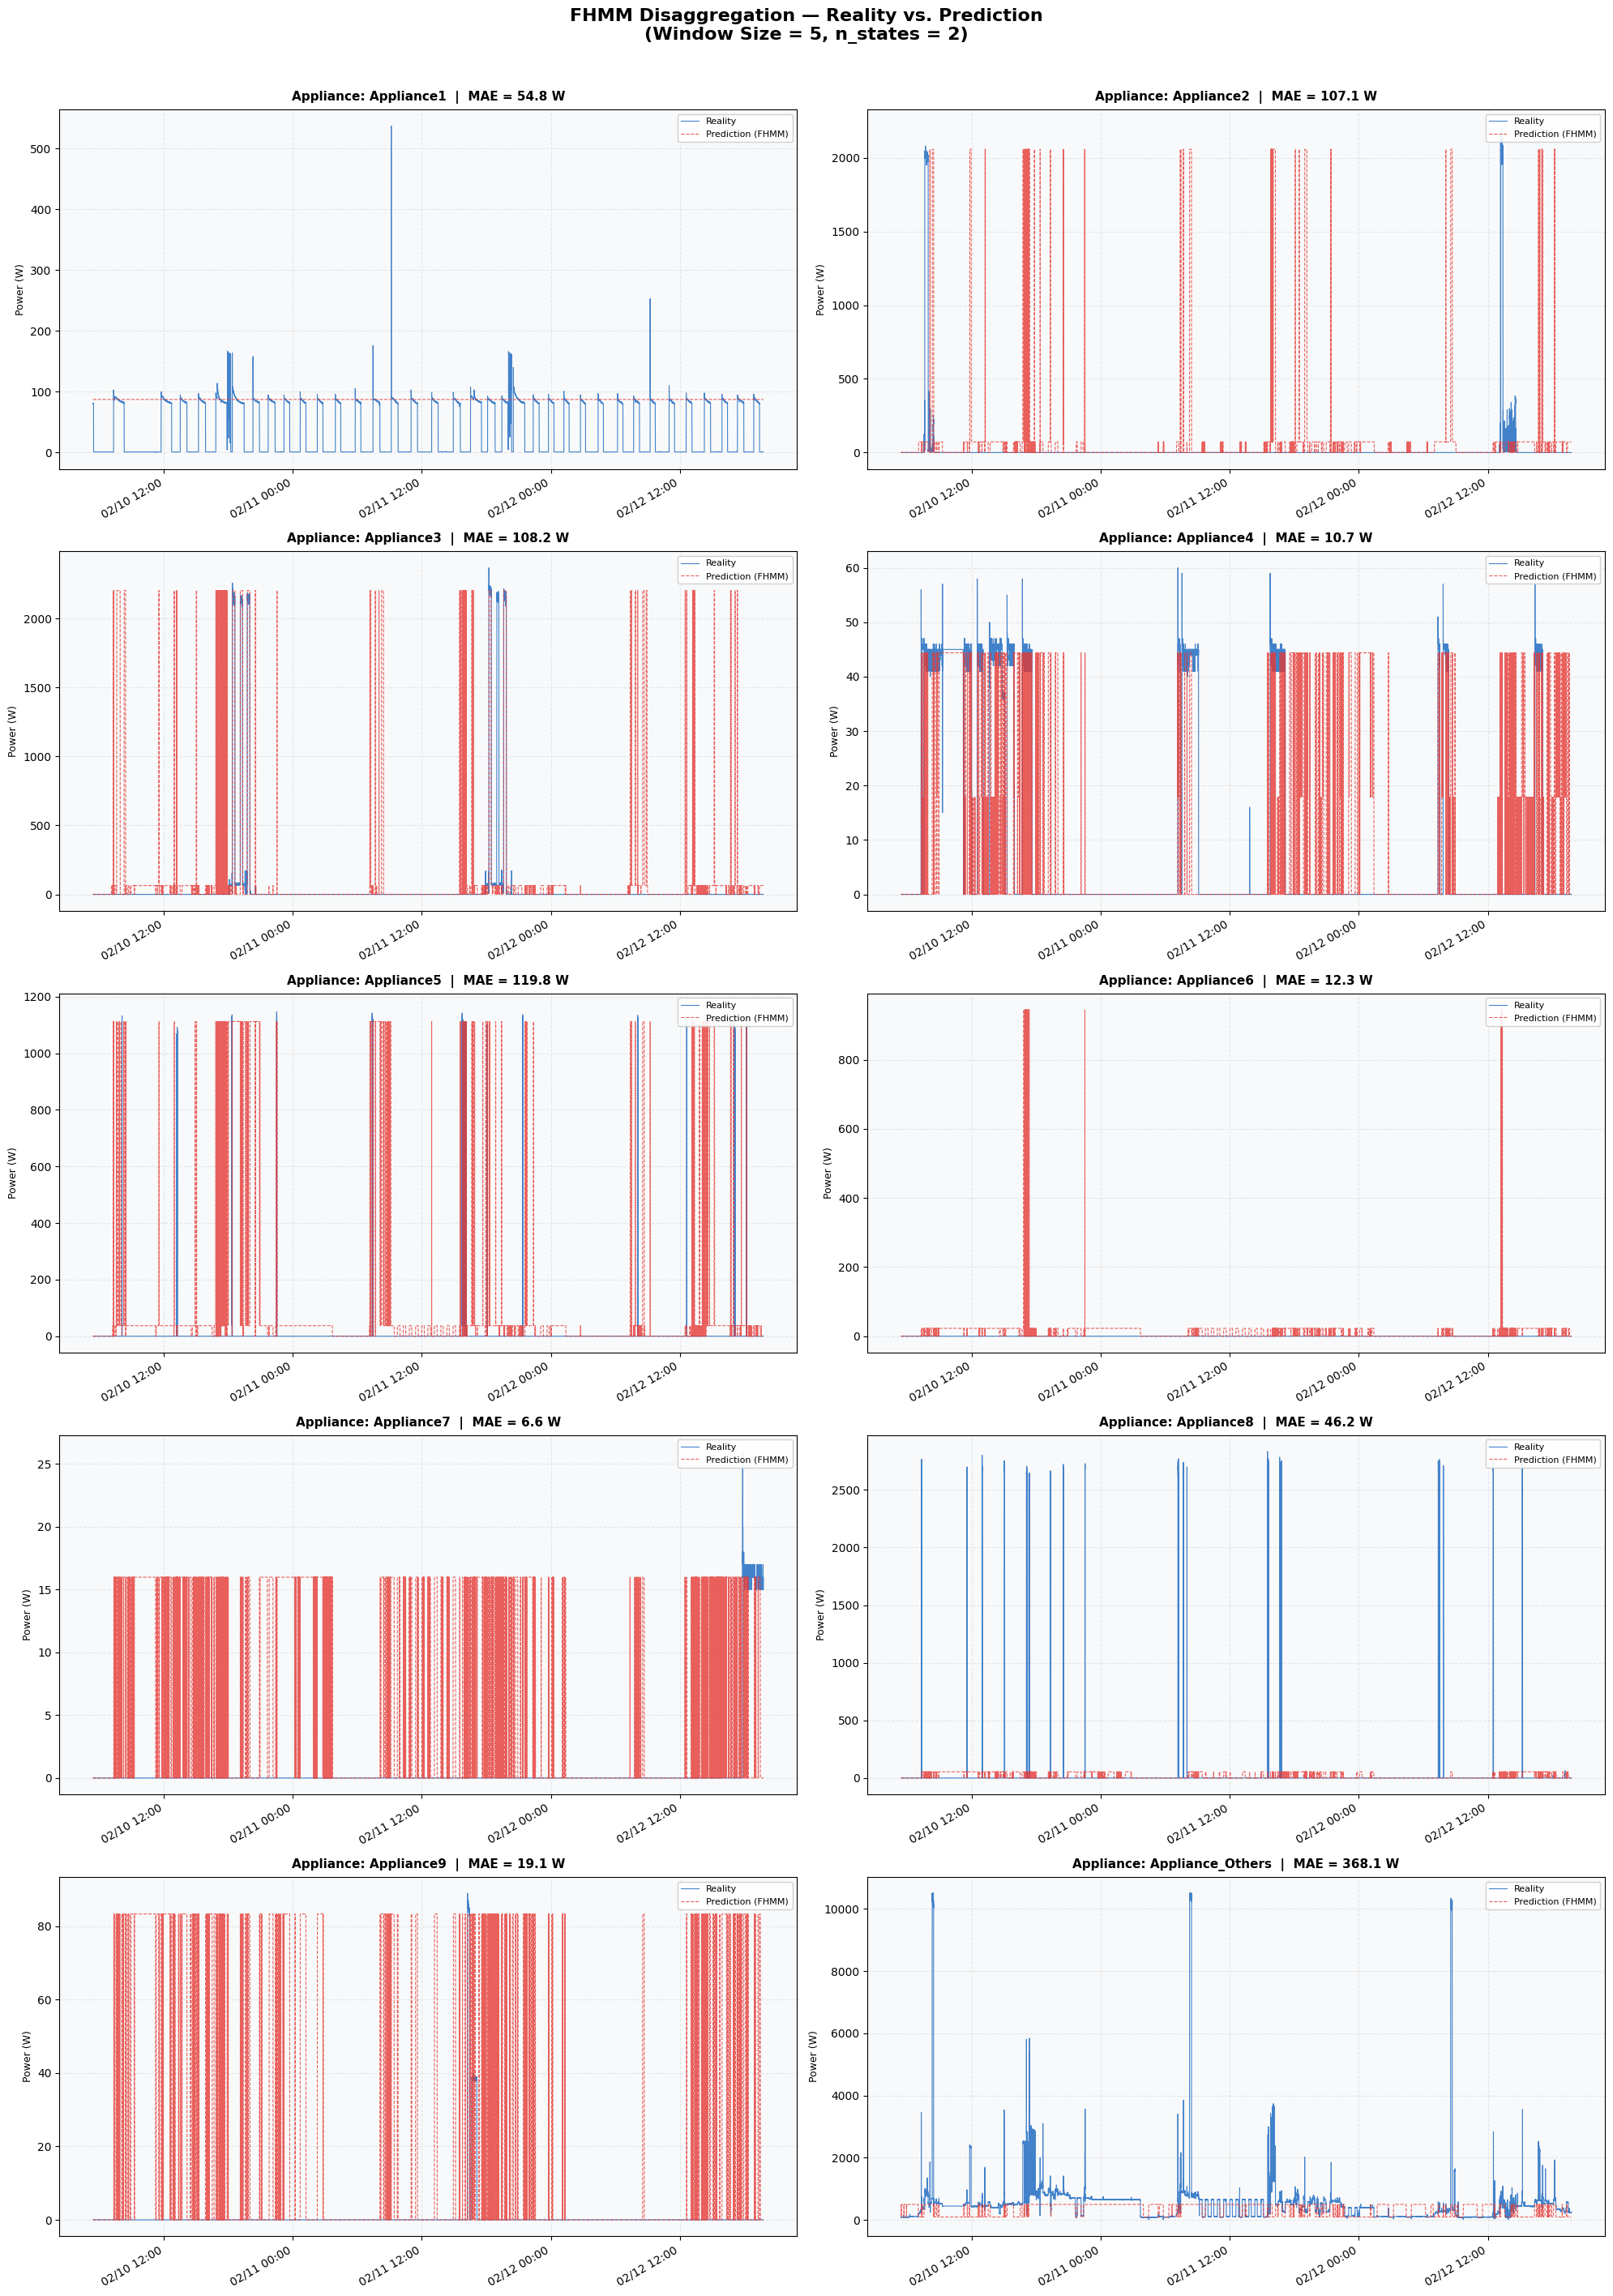

In [48]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

time_test = df_test['Time'].iloc[WINDOW_SIZE:].reset_index(drop=True)

N_PLOT = min(32_400, len(time_test))

all_appliances = ['Appliance1', 'Appliance2', 'Appliance3',
                  'Appliance4', 'Appliance5', 'Appliance6',
                  'Appliance7', 'Appliance8', 'Appliance9',
                  'Appliance_Others']

colors_actual = '#1565C0'  
colors_pred   = '#E53935' 

fig, axes = plt.subplots(5, 2, figsize=(20, 28))
axes = axes.flatten()  # chuyển từ 2D array sang 1D

for i, col in enumerate(all_appliances):
    ax = axes[i]
    
    t = time_test[:N_PLOT]
    actual = y_test[col].values[:N_PLOT]
    predicted = y_pred_df[col].values[:N_PLOT]
    
    ax.plot(t, actual, 
            color=colors_actual, linewidth=0.8, alpha=0.8,
            label='Reality', zorder=2)
    
    ax.plot(t, predicted, 
            color=colors_pred, linewidth=0.8, alpha=0.8,
            label='Prediction (FHMM)', linestyle='--', zorder=3)

    mae_val = np.abs(actual - predicted).mean()
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    
    ax.set_title(f'Appliance: {col}  |  MAE = {mae_val:.1f} W', 
                 fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel('Power (W)', fontsize=9)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.25, linestyle='--')
    
    ax.set_facecolor('#F8F9FA')

for j in range(len(all_appliances), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'FHMM Disaggregation — Reality vs. Prediction\n'
             f'(Window Size = {WINDOW_SIZE}, n_states = {fhmm.n_states})',
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()

# Save
output_path = os.path.join(base_dir, 'notebooks/fhmm', 'fhmm_results.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight')

plt.show()